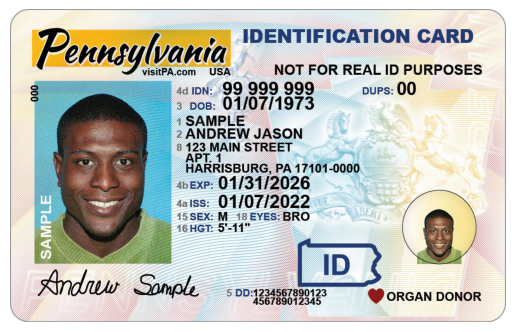

Image shape: (637, 1011, 3)


In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('sample_card.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()
print("Image shape:", img.shape)

In [2]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
print(f"Detected {len(faces)} faces.")
print("Face coordinates:", faces)

Detected 3 faces.
Face coordinates: [[843 426  65  65]
 [939 326  50  50]
 [ 85 225 215 215]]


Largest face at x=85, y=225, width=215, height=215


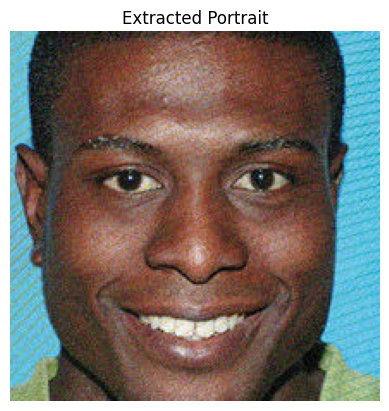

In [ ]:
# pick the largest face (biggest area = width * height)
largest_face = max(faces, key=lambda f: f[2] * f[3])

# x = largest_face[0]
# y = largest_face[1]
# w = largest_face[2]
# h = largest_face[3]
x, y, w, h = largest_face
print(f"Largest face at x={x}, y={y}, width={w}, height={h}")

# crop it out
portrait = img_rgb[y:y+h, x:x+w]

plt.imshow(portrait)
plt.axis('off')
plt.title('Extracted Portrait')
plt.show()

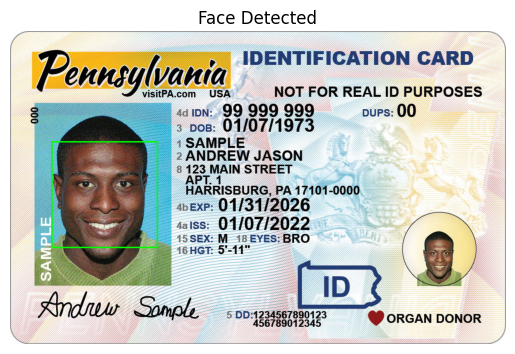

In [4]:
# make a copy so we don't mess up the original
img_copy = img_rgb.copy()

# draw rectangle around the face
x, y, w, h = largest_face
cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)
# (0, 255, 0) = green color, 2 = thickness

plt.imshow(img_copy)
plt.axis('off')
plt.title('Face Detected')
plt.show()

In [5]:
import os
print(os.path.exists(r'C:\Program Files\Tesseract-OCR\tesseract.exe'))

True


In [6]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
print("Path set to:", pytesseract.pytesseract.tesseract_cmd)

text = pytesseract.image_to_string(img_rgb)
print(text)

Path set to: C:\Program Files\Tesseract-OCR\tesseract.exe
IDENTIFICATION CARD
Penns pica (a |

visitPA.com USA
zion: 99 999 999
3 pos: 01/07/1973
4 SAMPLE 7
2 ANDREW JASON
8123 MAIN STREET
APT.1
HARRISBURG, PA 17101-0000
avexP: 01/31/2026
aaiss: 01/07/2022

15SEX:-M- 18 EYES: BRO
46HGT: 5'-11"

=a Sample 5 DD:1234567890123 @ ORGAN DONOR

456789012345




In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
upscaled = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
text2 = pytesseract.image_to_string(upscaled)
print(repr(text2))

'Ve com USA NOT FOR REAL ID PURPOSES\n4aipn: 99 999 999 pups: 00\ns pos: 01/07/1973\n\n1 SAMPLE\n2 ANDREW JASON\n8 Kee Yop STREET\n\nHARRISBURG, PA 17101-0000\n_ 4vexP: 01/31/2026\n_aaiss: 01/07/2022\n\n— 45SEX: M18 EYES:BRO\n46 HGT: 5\'-11"\n\nbi Mt Le ; ID ¢ & GJ\n/ t ww Sample 5 DD:1234567890123 @ ORGAN DONOR\n\n456789012345\n\nIDENTIFICATION CARD >\n| Pes ENT\n\n'


In [8]:
import re

# find date of birth
dob = re.search(r'DOB[:\s]+(\d{2}/\d{2}/\d{4})', text)
if dob:
    print("DOB found:", dob.group(1))

# find expiry date
exp = re.search(r'EXP[:\s]+(\d{2}/\d{2}/\d{4})', text)
if exp:
    print("Expiry found:", exp.group(1))

# find name - look for pattern after "SAMPLE" line
name = re.search(r'\d\s([A-Z]+\s[A-Z]+)', text)
if name:
    print("Name found:", name.group(1))

Name found: ANDREW JASON


In [9]:
print(repr(text))

'IDENTIFICATION CARD\nPenns pica (a |\n\nvisitPA.com USA\nzion: 99 999 999\n3 pos: 01/07/1973\n4 SAMPLE 7\n2 ANDREW JASON\n8123 MAIN STREET\nAPT.1\nHARRISBURG, PA 17101-0000\navexP: 01/31/2026\naaiss: 01/07/2022\n\n15SEX:-M- 18 EYES: BRO\n46HGT: 5\'-11"\n\n=a Sample 5 DD:1234567890123 @ ORGAN DONOR\n\n456789012345\n\n'


In [10]:
import re
# find ALL dates in the text
all_dates = re.findall(r'\d{2}/\d{2}/\d{4}', text2)
print("All dates found:", all_dates)

# first date = DOB, second = EXP, third = ISS
if len(all_dates) >= 1:
    print("DOB:", all_dates[0])
if len(all_dates) >= 2:
    print("Expiry:", all_dates[1])
if len(all_dates) >= 3:
    print("Issue date:", all_dates[2])

All dates found: ['01/07/1973', '01/31/2026', '01/07/2022']
DOB: 01/07/1973
Expiry: 01/31/2026
Issue date: 01/07/2022


In [11]:
from paddleocr import PaddleOCR

# initialize - first run will download models (~500mb)
ocr = PaddleOCR(use_angle_cls=True, lang='en')

# run on our image
result = ocr.ocr('sample_card.jpg')

# print results
for line in result[0]:
    print(line[1][0])  # just the text part

ModuleNotFoundError: No module named 'paddleocr'

In [ ]:
import easyocr

# initialize with English - first run downloads models
reader = easyocr.Reader(['en'])

# this returns a list
result = reader.readtext('sample_card.jpg')

# print results
for detection in result:
    text = detection[1]        # the actual text
    confidence = detection[2]  # how confident it is (0 to 1)
    print(f"{text} (confidence: {confidence:.2f})")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

c:\Users\swali\anaconda3\envs\photoBot\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


IDENTIFICATION CARD (confidence: 1.00)
Pennsylvania (confidence: 0.87)
visitPA.com (confidence: 0.99)
USA (confidence: 1.00)
NOT FOR REAL ID PURPOSES (confidence: 0.91)
4d IDN: (confidence: 0.67)
99 (confidence: 1.00)
39,8991999 (confidence: 0.26)
DUPS: (confidence: 1.00)
00 (confidence: 0.97)
DOB: (confidence: 1.00)
SAMPLE (confidence: 0.63)
ANDREW JASON (confidence: 0.99)
123 MAIN STREET (confidence: 0.83)
AARRISBURG, PA 17101-0000 (confidence: 0.78)
4b EXP: (confidence: 0.99)
01/31/2026 (confidence: 1.00)
4aISS: (confidence: 1.00)
01/07/2022 (confidence: 1.00)
15 SEX: M (confidence: 0.99)
48 EYES: BRO (confidence: 0.93)
1 (confidence: 0.54)
16HGT: 5'11 (confidence: 0.92)
ID (confidence: 1.00)
Andnlu   Sompl (confidence: 0.39)
DD:138489882313* (confidence: 0.29)
ORGAN DONOR (confidence: 0.72)
EA (confidence: 0.25)


In [12]:
# find DOB - look for date after "DOB:" text
dob_found = False
for i, detection in enumerate(result):
    text = detection[1]
    if 'DOB' in text.upper():
        # date is usually the next detection
        print("DOB line:", text)
        if i+1 < len(result):
            print("Next item:", result[i+1][1])

DOB line: DOB:
Next item: SAMPLE


In [13]:
for i, detection in enumerate(result):
    text = detection[1]
    if 'DOB' in text.upper():
        print("DOB label:", text)
        print("i+1:", result[i+1][1])
        print("i+2:", result[i+2][1])

DOB label: DOB:
i+1: SAMPLE
i+2: ANDREW JASON


In [15]:
# join all detected text into one string
full_text = ' '.join([d[1] for d in result])
print(full_text)

IDENTIFICATION CARD Pennsylvania visitPA.com USA NOT FOR REAL ID PURPOSES 4d IDN: 99 39,8991999 DUPS: 00 DOB: SAMPLE ANDREW JASON 123 MAIN STREET AARRISBURG, PA 17101-0000 4b EXP: 01/31/2026 4aISS: 01/07/2022 15 SEX: M 48 EYES: BRO 1 16HGT: 5'11 ID Andnlu   Sompl DD:138489882313* ORGAN DONOR EA


In [17]:
# print each detection with its index
for i, detection in enumerate(result):
    print(i, detection[1])

0 IDENTIFICATION CARD
1 Pennsylvania
2 visitPA.com
3 USA
4 NOT FOR REAL ID PURPOSES
5 4d IDN:
6 99
7 39,8991999
8 DUPS:
9 00
10 DOB:
11 SAMPLE
12 ANDREW JASON
13 123 MAIN STREET
14 AARRISBURG, PA 17101-0000
15 4b EXP:
16 01/31/2026
17 4aISS:
18 01/07/2022
19 15 SEX: M
20 48 EYES: BRO
21 1
22 16HGT: 5'11
23 ID
24 Andnlu   Sompl
25 DD:138489882313*
26 ORGAN DONOR
27 EA


In [36]:
possible_names = re.findall(r'\b[A-Z]{2,}(?:\s+[A-Z]{2,})+\b', full_text)

ignore_words = [
    "CARD", "IDENTIFICATION", "IDENTITY",
    "LICENSE", "LICENCE", "DRIVING",
    "PASSPORT", "NATIONAL",
    "GOVERNMENT", "GOVT",
    "REPUBLIC", "STATE", "COUNTRY",
    "USA", "UAE", "INDIA",
    "EMIRATES", "AUTHORITY",

    "ID", "NO", "NUMBER",
    "DOB", "EXP", "ISS",
    "SEX", "HEIGHT", "HGT",
    "EYES", "HAIR", "DOB:",
    "DATE", "BIRTH",

    "ADDRESS", "STREET", "ROAD",
    "CITY", "STATE", "ZIP",
    "POSTAL", "CODE",

    "REAL", "PURPOSES",
    "DONOR", "ORGAN", "SAMPLE"

    "MALE", "FEMALE",
    "M", "F",

    "SIGNATURE", "HOLDER",
    "NATIONALITY",

    "DEPARTMENT", "MINISTRY",
    "TRANSPORT", "TRAFFIC",

    "VISIT", "VISITOR",

    "DOCUMENT", "OFFICIAL",

    "THE", "AND", "FOR"

    ]


In [37]:
filtered = []

for name in possible_names:
    words = name.split()
    if len(words) < 2 or len(words) > 4:
        continue
    if any(word in ignore_words for word in words):
        continue
    filtered.append(name)

    print(filtered)

['SAMPLE ANDREW JASON']


In [16]:
import re

# find all dates
all_dates = re.findall(r'\d{2}/\d{2}/\d{4}', full_text)
print("All dates:", all_dates)

# find name - text after DOB: before the date
name = re.search(r'DOB:\s+(\w+\s+\w+)', full_text)
if name:
    print("Name:", name.group(1))

# find sex
sex = re.search(r'SEX:\s+(\w)', full_text)
if sex:
    print("Sex:", sex.group(1))

# find expiry specifically
exp = re.search(r'EXP:\s+(\d{2}/\d{2}/\d{4})', full_text)
if exp:
    print("Expiry:", exp.group(1))

All dates: ['01/31/2026', '01/07/2022']
Name: SAMPLE ANDREW
Sex: M
Expiry: 01/31/2026


In [18]:
result_passport = reader.readtext('psprt.jpg')
for i, detection in enumerate(result_passport):
    print(i, detection[1])

c:\Users\swali\anaconda3\envs\photoBot\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0 HRd TunY
1 REPUBLIC OF INDIA
2 cTfy / Type
3 cly / Cede
4 eraRlal / Natianallty
5 4T84d 7 / Passport
6 p
7 IND
8 HRdly
9 INDIAN
10 Zooooo00
11 37F / Suiname
12 SPECIMEN
13 Rn 'RI 4/ Given Namets)
14 KUMAR
15 6
16 3704
17 Date 0/ Bith
18 67T
19 Sex
20 24/05/1985
21 M
22 07{F/ Flace ol Birth
23 MUMBA I ,
24 MAHARASHTRA
25 G0+n#R4/ Flace 0f Issue
26 BANGALORE
27 3n+AFl Date of Issue
28 74T & ffr / Date of Expiry
29 01/01/2013
30 01/01/2023
31 P<SPECIMEN<<KUMAR<G<<<<<<<<<<<<K<<K<<<<<<<<<
32 29999999<0IND8505246m2300000<<<<<<<<<<<<<<<4
33 Ko
34 Nlole


In [22]:
mrz_line1 = result_passport[31][1]
mrz_line2 = result_passport[32][1]

print("Line 1:", mrz_line1)
print("Line 2:", mrz_line2)

doc_type = mrz_line1[0]
country = mrz_line1[2:5]
names = mrz_line1[5:].split('<<')
surname = names[0].replace('<', ' ').strip()
given_name = names[1].replace('<', ' ').strip() if len(names) > 1 else ''


print("\n--- Parsed ---")
print("Doc type:", doc_type)
print("Country:", country)
print("Surname:", surname)
print("Given name:", given_name)

Line 1: P<SPECIMEN<<KUMAR<G<<<<<<<<<<<<K<<K<<<<<<<<<
Line 2: 29999999<0IND8505246m2300000<<<<<<<<<<<<<<<4

--- Parsed ---
Doc type: P
Country: SPE
Surname: CIMEN
Given name: KUMAR G


In [31]:
line2 = mrz_line2
passport_number = line2[0:8]
nationality = line2[10:13]
dob = line2[13:19]
sex = line2[20] 
expiry = line2[21:27]

if int(dob[0:2]) > 30:
    dob = '19' + dob
else:
    dob = '20' + dob

if int(expiry[0:2]) > 30:
    expiry = '19' + expiry
else:
    expiry = '20' + expiry

modified_dob = f"{dob[0:4]}/{dob[4:6]}/{dob[6:8]}"
modified_expiry = f"{expiry[0:4]}/{expiry[4:6]}/{expiry[6:8]}"
print("Passport number:", passport_number)
print("Nationality:", nationality)
print("DOB:", modified_dob)
print("Sex:", sex)
print("Expiry:", modified_expiry)

Passport number: 29999999
Nationality: IND
DOB: 1985/05/24
Sex: m
Expiry: 2023/00/00
